# 실습 02 · Iris 표형 데이터 MLP 다중분류

**목표**

- 표형 데이터의 `(sample, feature, label)` 구조를 확인한다.
- train 통계량만 사용해 표준화하고 `DataLoader`를 만든다.
- `(batch, 4) → (batch, 3)` MLP를 학습·검증한다.
- hidden width 변경이 학습 곡선에 미치는 영향을 예상한다.

## 1. 환경·로컬 데이터 경로

In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
from pathlib import Path

def find_project_root(start=None):
    """노트북 위치가 달라도 프로젝트의 로컬 데이터를 찾습니다."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("data 폴더를 찾지 못했습니다. 노트북과 같은 위치(또는 상위)에 data 폴더가 있어야 합니다.")

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
print("project:", PROJECT_ROOT.name)
print("data exists:", DATA_ROOT.exists())


project: edu_0814
data exists: True


In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IRIS_PATH = DATA_ROOT / "Iris.csv"
assert IRIS_PATH.exists(), IRIS_PATH
print("device:", DEVICE)


device: cpu


## 2. 데이터 읽기: sample·feature·label

In [4]:
iris = pd.read_csv(IRIS_PATH)
display(iris.head())
print("rows, columns:", iris.shape)
print("columns:", iris.columns.tolist())
print("missing values:", int(iris.isna().sum().sum()))


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


rows, columns: (150, 6)
columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
missing values: 0


## 수치 feature의 분포 확인

평균과 표준편차, 최솟값과 최댓값은 scaling이 필요한 이유를 보여 줍니다.

In [5]:
display(iris.drop(columns="Id").describe().round(2))


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


`Id`는 행 식별자이므로 feature에서 제외합니다. `Species`가 label이고 나머지 4개 측정값이 feature입니다.

In [6]:
feature_cols = [c for c in iris.columns if c not in {"Id", "Species"}]
class_names = sorted(iris["Species"].unique())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
X = iris[feature_cols].to_numpy(dtype=np.float32)
y = iris["Species"].map(class_to_idx).to_numpy(dtype=np.int64)
print("X:", X.shape, "y:", y.shape)
print("class mapping:", class_to_idx)


X: (150, 4) y: (150,)
class mapping: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}


## 3. 짧은 EDA: class와 feature 범위

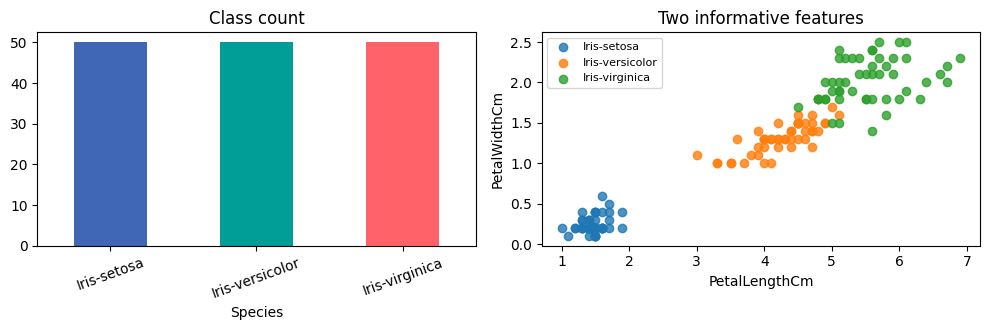

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
iris["Species"].value_counts().sort_index().plot.bar(ax=axes[0], color=["#3F67B5", "#009E96", "#FF6369"])
axes[0].set_title("Class count"); axes[0].tick_params(axis="x", rotation=20)
for name in class_names:
    part = iris[iris["Species"] == name]
    axes[1].scatter(part["PetalLengthCm"], part["PetalWidthCm"], label=name, alpha=.8)
axes[1].set_xlabel("PetalLengthCm"); axes[1].set_ylabel("PetalWidthCm"); axes[1].legend(fontsize=8)
axes[1].set_title("Two informative features"); plt.tight_layout(); plt.show()


EDA의 목적은 모델을 고르는 데 필요한 데이터 구조를 확인하는 것입니다. 여기서는 class 균형과 feature scale을 확인합니다.

## feature 간 관계 확인

상관계수는 선형 관계의 방향을 빠르게 살펴보는 도구입니다. 원인 관계를 의미하지는 않습니다.

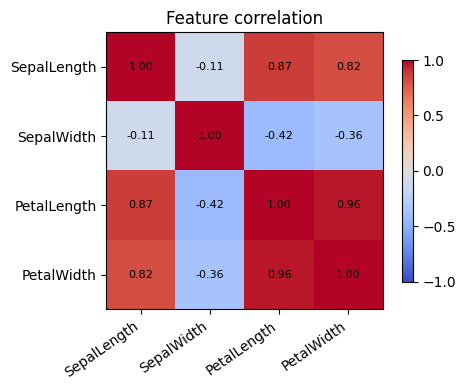

In [8]:
corr = iris[feature_cols].corr()
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(feature_cols)), [c.replace("Cm", "") for c in feature_cols], rotation=35, ha="right")
ax.set_yticks(range(len(feature_cols)), [c.replace("Cm", "") for c in feature_cols])
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, shrink=.8); ax.set_title("Feature correlation"); plt.tight_layout(); plt.show()


## 4. train/validation/test 분할

In [9]:
indices = np.arange(len(y))
train_idx, temp_idx = train_test_split(indices, test_size=.40, stratify=y, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=.50, stratify=y[temp_idx], random_state=SEED)
print("split sizes:", len(train_idx), len(val_idx), len(test_idx))
print("train class count:", np.bincount(y[train_idx]))


split sizes: 90 30 30
train class count: [30 30 30]


validation은 학습 중 설정을 확인하고, test는 마지막에 한 번 확인합니다. 같은 관측치가 둘 이상의 split에 들어가지 않습니다.

## 5. train-only 표준화

In [10]:
scaler = StandardScaler().fit(X[train_idx])
X_train = scaler.transform(X[train_idx]).astype(np.float32)
X_val = scaler.transform(X[val_idx]).astype(np.float32)
X_test = scaler.transform(X[test_idx]).astype(np.float32)
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]
print("train mean:", np.round(X_train.mean(axis=0), 3))
print("val mean (같을 필요 없음):", np.round(X_val.mean(axis=0), 3))


train mean: [-0. -0.  0. -0.]
val mean (같을 필요 없음): [-0.009  0.06  -0.023  0.049]


**누수 방지 경계:** `fit`은 train에서만, `transform`은 train/validation/test 각각에 적용합니다.

## 6. Dataset·DataLoader와 shape

In [11]:
def make_loader(X_array, y_array, batch_size, shuffle):
    dataset = TensorDataset(torch.from_numpy(X_array), torch.from_numpy(y_array))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0)

BATCH_SIZE = 16
train_loader = make_loader(X_train, y_train, BATCH_SIZE, True)
val_loader = make_loader(X_val, y_val, BATCH_SIZE, False)
test_loader = make_loader(X_test, y_test, BATCH_SIZE, False)
xb, yb = next(iter(train_loader))
print("input batch:", xb.shape, xb.dtype)
print("label batch:", yb.shape, yb.dtype)


input batch: torch.Size([16, 4]) torch.float32
label batch: torch.Size([16]) torch.int64


**Shape checkpoint:** 입력 `(batch, 4)`, 정답 `(batch,)`. CrossEntropyLoss는 class index 형태의 `long` 정답을 사용합니다.

## 7. MLP 정의

In [12]:
HIDDEN_DIM = 16  # 학습자 변경 변수

class IrisMLP(nn.Module):
    def __init__(self, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 3),
        )
    def forward(self, x):
        return self.net(x)

model = IrisMLP().to(DEVICE)
with torch.no_grad():
    sample_logits = model(xb.to(DEVICE))
print(model)
print("input → logits:", xb.shape, "→", sample_logits.shape)


IrisMLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=3, bias=True)
  )
)
input → logits: torch.Size([16, 4]) → torch.Size([16, 3])


출력에는 softmax를 붙이지 않습니다. `CrossEntropyLoss`가 logit과 정답 index를 안정적으로 처리합니다.

## 8. 학습·검증 함수

In [13]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = total_correct = total_count = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if training:
            optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            logits = model(xb)
            loss = criterion(logits, yb)
            if training:
                loss.backward(); optimizer.step()
        total_loss += loss.item() * len(yb)
        total_correct += (logits.argmax(1) == yb).sum().item()
        total_count += len(yb)
    return total_loss / total_count, total_correct / total_count


## 선형 기준 모델

은닉층이 없는 `Linear(4,3)`을 먼저 학습하면 MLP가 실제로 추가 가치를 주는지 비교할 기준이 생깁니다.

In [14]:
torch.manual_seed(SEED)
linear_model = nn.Linear(4, 3).to(DEVICE)
linear_optimizer = torch.optim.Adam(linear_model.parameters(), lr=.01)
linear_criterion = nn.CrossEntropyLoss()
linear_history = []
for epoch in range(30):
    run_epoch(linear_model, train_loader, linear_criterion, linear_optimizer)
    linear_history.append(run_epoch(linear_model, val_loader, linear_criterion))
print(f"linear validation: loss={linear_history[-1][0]:.3f}, accuracy={linear_history[-1][1]:.3f}")
print("linear parameters:", sum(p.numel() for p in linear_model.parameters()))


linear validation: loss=0.342, accuracy=0.867
linear parameters: 15


## 9. MLP 학습

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
EPOCHS = 50
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc = run_epoch(model, val_loader, criterion)
    for key, value in zip(history, [tr_loss, va_loss, tr_acc, va_acc]):
        history[key].append(value)
    if epoch in {1, 10, 20, 30, 40, 50}:
        print(f"{epoch:02d} | train {tr_loss:.3f}/{tr_acc:.3f} | val {va_loss:.3f}/{va_acc:.3f}")


01 | train 1.085/0.411 | val 0.964/0.600
10 | train 0.225/0.944 | val 0.276/0.867


20 | train 0.101/0.967 | val 0.137/0.967


30 | train 0.065/0.967 | val 0.085/0.967
40 | train 0.050/0.978 | val 0.073/0.967


50 | train 0.042/0.989 | val 0.064/1.000


## 10. 학습 곡선 해석

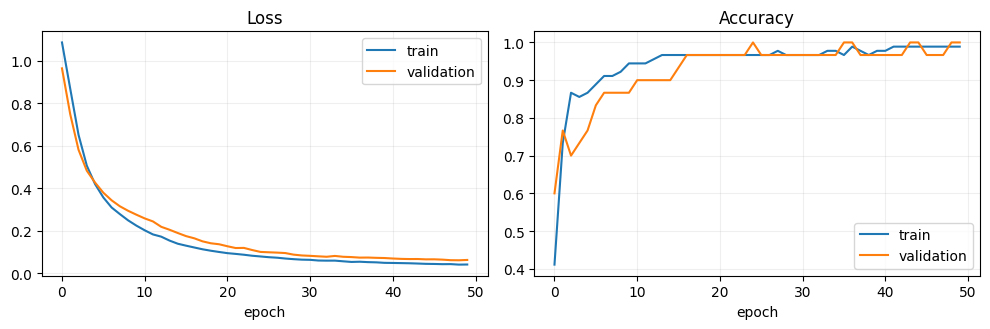

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(history["train_loss"], label="train"); axes[0].plot(history["val_loss"], label="validation")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(alpha=.2)
axes[1].plot(history["train_acc"], label="train"); axes[1].plot(history["val_acc"], label="validation")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(alpha=.2)
plt.tight_layout(); plt.show()


train loss만 내려가고 validation loss가 올라가면 과적합 신호입니다. Iris는 데이터가 작으므로 곡선이 다소 흔들릴 수 있습니다.

## 11. 마지막 test 확인

In [17]:
test_loss, test_acc = run_epoch(model, test_loader, criterion)
print(f"test loss={test_loss:.3f}, test accuracy={test_acc:.3f}")


test loss=0.110, test accuracy=0.967


## 예측 확률과 오분류 사례 확인

전체 정확도 하나보다 어떤 sample에서 확신이 낮거나 잘못 예측했는지 확인하는 것이 모델 개선에 더 직접적입니다.

In [18]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_test).to(DEVICE)
    probabilities = model(X_test_tensor).softmax(dim=1).cpu().numpy()
predictions = probabilities.argmax(axis=1)
review = pd.DataFrame({
    "true": [class_names[i] for i in y_test],
    "pred": [class_names[i] for i in predictions],
    "confidence": probabilities.max(axis=1).round(3),
})
display(review.sort_values("confidence").head(10))
print("misclassified:", int((predictions != y_test).sum()), "/", len(y_test))


,true,pred,confidence
11,Iris-virginica,Iris-virginica,0.518
29,Iris-virginica,Iris-virginica,0.530
10,Iris-virginica,Iris-virginica,0.793
23,Iris-virginica,Iris-versicolor,0.795
2,Iris-versicolor,Iris-versicolor,0.948
13,Iris-versicolor,Iris-versicolor,0.962
24,Iris-versicolor,Iris-versicolor,0.975
4,Iris-virginica,Iris-virginica,0.979
28,Iris-virginica,Iris-virginica,0.982
0,Iris-versicolor,Iris-versicolor,0.986


misclassified: 1 / 30


## 모델 복잡도 비교

선형 모델과 MLP의 파라미터 수와 validation 결과를 함께 보면 복잡도가 항상 성능 향상으로 이어지는지 판단할 수 있습니다.

In [19]:
comparison = pd.DataFrame([
    {"model": "Linear", "parameters": sum(p.numel() for p in linear_model.parameters()), "val_accuracy": linear_history[-1][1]},
    {"model": "MLP", "parameters": sum(p.numel() for p in model.parameters()), "val_accuracy": history["val_acc"][-1]},
])
display(comparison.round(3))


,model,parameters,val_accuracy
0,Linear,15,0.867
1,MLP,131,1.000


정확도는 수업 중 학습 상태를 확인하는 값입니다. 현업에서는 class 비용, 데이터 이동, 불확실성 등을 별도로 검토해야 합니다.

## 12. 학습자 변경 과제: hidden width

`HIDDEN_DIM`을 4 또는 64로 바꾸고 **모델 생성부터 다시 실행**하세요.

- 4: 표현 용량이 작아 학습이 느리거나 제한될 수 있습니다.
- 64: train 성능은 빨리 좋아질 수 있지만 작은 데이터에서는 validation 변동이 커질 수 있습니다.

기록: `파라미터 수 → 곡선 변화 → 현업에서 선택할 기준` 순서로 한 문장을 작성하세요.

In [20]:
parameter_count = sum(p.numel() for p in model.parameters())
print("parameters:", parameter_count)
print("관찰 기록: hidden_dim=___에서 validation 곡선은 ___했다.")


parameters: 131
관찰 기록: hidden_dim=___에서 validation 곡선은 ___했다.


## 빠른 hidden width 비교

같은 split과 학습률에서 은닉 차원만 바꾸어 validation 곡선의 차이를 확인합니다.

In [21]:
width_results = []
for width in [4, 16, 64]:
    torch.manual_seed(SEED)
    candidate = IrisMLP(hidden_dim=width).to(DEVICE)
    candidate_optimizer = torch.optim.Adam(candidate.parameters(), lr=.01)
    for _ in range(25):
        run_epoch(candidate, train_loader, criterion, candidate_optimizer)
    candidate_loss, candidate_acc = run_epoch(candidate, val_loader, criterion)
    width_results.append({"hidden": width, "parameters": sum(p.numel() for p in candidate.parameters()), "val_loss": candidate_loss, "val_accuracy": candidate_acc})
display(pd.DataFrame(width_results).round(3))


,hidden,parameters,val_loss,val_accuracy
0,4,35,0.268,0.933
1,16,131,0.094,0.933
2,64,515,0.066,1.000
